# HQ-Relocation — a quantitative teardown 🔬
### Market-model CAR on a relocation table · tax vs other buckets · a Welch *t* + placebo randomization null · the announcement-day vs holdable-window split · a lagged drift leg + costs · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Signal_or_distraction%3F: Non-event](https://img.shields.io/badge/Signal_or_distraction%3F-Non--event-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We treat the folklore as a **market-model event-study hypothesis** — a positive announcement CAR (the 'signal' camp) or a negative post-announcement drift (the 'distraction' camp), sorted by the move's tax vs other motive — and confront it with the **sample size** and with **salience selection**. The decisive objects are a cross-section of 20 abnormal-return events and a placebo null sized to that count.

> ⚠️ **Data + selection note.** The relocation table is hardcoded and transparent (~20 real moves, 2010–2025); the tape is **salience-selected** (the moves famous enough to date) and **survivor-only** (named on the Signal axis), and the tax/other label is the believers' own, subjective framing. Real data: yfinance daily adjusted closes, 2010→2026-06-30 (as-of), fingerprint **3fdda93c2d9a**. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hq_relocation import data, strategy as st

AS_OF = "2026-06-30"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EVENTS = data.load_real()
    PRICES = PRICES[PRICES.index <= AS_OF]
    PANEL = st.car_panel(PRICES, EVENTS)                 # canonical CAR[0,+2]
else:
    PRICES = EVENTS = PANEL = None
print("real HQ-move cache present:", HAVE_REAL,
      "| events priced:", (0 if PANEL is None else len(PANEL)),
      "| table fingerprint:", data.fingerprint(data.HQ_MOVES))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_table': 20, 'n_priced': 20, 'n_tax': 14, 'n_other': 6, 'as_of': '2026-06-30', 'fingerprint': '3fdda93c2d9a', 'car_tax': (0.45, 50, 0.35), 'car_other': (-0.4, 67, -0.35), 'car_all': (0.2, 55, 0.21), 'diff_pct': 0.85, 'diff_t': 0.5, 'all_placebo_p': 0.735, 'day00': (0.18, 0.23, 55, 0.588), 'drift21': (-0.06, -0.03, 0.85, 0.26, -0.16, None, None), 'drift63': (3.39, 1.34, 4.66, 1.46, 3.29, 0.301, 70), 'robust': [('[0,0]', 0.18, 0.23, -0.49, -0.41), ('[0,+2]', 0.2, 0.21, 0.85, 0.5), ('[-1,+1]', 1.1, 0.88, 0.23, 0.12), ('[0,+4]', 0.34, 0.32, 1.86, 0.97)], 'syn': [(0.0, -0.43, -0.49, -1.1, 0.45), (500.0, 4.57, 5.12, -1.1, 3.79)]}


real HQ-move cache present: True | events priced: 20 | table fingerprint: 3fdda93c2d9a


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | CAR[0,+2] **+0.20%** (Welch **t = 0.21**, placebo **p = 0.73**); day-one **+0.18%** (**t = 0.23**); tax−other **+0.85pp** (**t = 0.50**); quarter drift **+3.4%** (**t = 1.34**). Nothing clears t = 1. |
| **Tradability** | `MIRAGE` | no day-one repricing and no significant drift; the one whiff (+3.4%/qtr, net +3.3%) is un-certifiable and beta-in-disguise on a 20-name survivor tape. |
| **Signal or distraction?** | `NON-EVENT` | both camps fail — no significant +pop (no signal), no significant −drift (no distraction). |

> 💡 In plain words: an HQ move is a strategic, long-horizon decision that the market has largely anticipated and that carries no clean short-window catalyst — so neither the 'buy the tax saving' nor the 'fade the theatre' story survives contact with the tape.

## 1 · The claim, steelmanned

For event $i$ with announcement day $\tau_i$, fit the **market model** $r_{i,t} = \alpha_i + \beta_i r_{m,t} + \varepsilon_{i,t}$ on a clean estimation window $[\tau_i - g - L,\ \tau_i - g]$ ($L=120$ days, gap $g=10$), and cumulate the **abnormal return** $\mathrm{CAR}_i[a,b] = \sum_{t=\tau_i+a}^{\tau_i+b}(r_{i,t} - \hat\alpha_i - \hat\beta_i r_{m,t})$.

- **H₁ (signal / pop).** $\mathbb{E}[\mathrm{CAR}_i[0,2]] > 0$ — the market prices the move in (Desai-Hines found a small positive inversion effect).
- **H₂ (the reason sorts it).** $\mathbb{E}[\mathrm{CAR}\mid \text{tax}] > \mathbb{E}[\mathrm{CAR}\mid \text{other}]$ — tax-driven moves beat talk of 'talent'.
- **H₃ (drift / deployable).** $\mathbb{E}[\mathrm{CAR}_i[+1,+63]] \ne 0$ and harvestable net of costs — the slow repricing the 'signal' camp needs.

We find **H₁ not supported** (CAR $\approx 0$, $t\approx 0.2$, placebo $p=0.74$), **H₂ rejected** (the gap is $+0.85$pp at $t=0.50$, and 'other' wins *more* often), **H₃ not supported** ($+3.4\%$/qtr at $t=1.34$, inside its placebo). The distraction camp fares no better — the drift is *positive*, not negative. It is a **non-event**.

## 2 · So what? — what rides on each answer

The teardown is a set of one- and two-sample tests on small cross-sections, judged by their **standard error** and by a **randomization null**:

$$t_{\text{bucket}} = \frac{\overline{\mathrm{CAR}}}{s/\sqrt{k}},\qquad k\in\{6,14,20\}.$$

With $k\le 20$ and daily-return volatility over multi-day windows, $s/\sqrt{k}$ is large — a sub-percent mean drowns in its own SE. Worse, the sample is **conditioned on salience**: we see the moves memorable enough to date, by firms that survived. The honest instrument is a **placebo test**: resample $k$ random non-event windows on the same tickers (same market-model machinery) and ask how often chance matches the observed CAR. That randomization $p$, not the point estimate, decides the Signal axis.

## 3 · How we'd know — the protocol

- **Relocation table.** ~20 documented HQ moves 2010–2025 (**14** tax/incentive, **6** other), hardcoded & transparent; famous un-priceable moves (Burger King, Mylan, Walgreens' *abandoned* inversion) are listed for the selection caveat.
- **Abnormal returns.** Market model $r = \alpha+\beta\,r_{SPY}$, 120-day estimation window, 10-day gap; CAR over the event window.
- **Null #1 (Welch t).** Each bucket's mean CAR vs zero; the tax−other two-sample t.
- **Null #2 (placebo).** 20,000 draws of $k$ random non-event windows on the same tickers; $p = \Pr[|\text{random mean}| \ge |\text{observed}|]$ — the small-sample workhorse.
- **Drift + costs.** A [+1,+63] leg entered the day after the headline, net of a one-way 10-bps large-cap round trip.
- **Positive control.** Deterministic panels with a **planted** tax-bucket CAR edge: the inference must recover a large edge **and** must NOT manufacture significance when the edge is zero.

## 4 · The teardown

### 4a · The buckets — nothing, and the reason doesn't sort it

Mean CAR[0,+2] per bucket with $\pm$ standard error, against zero (dashed). Tax and other straddle zero; the gap is inside the error bars.

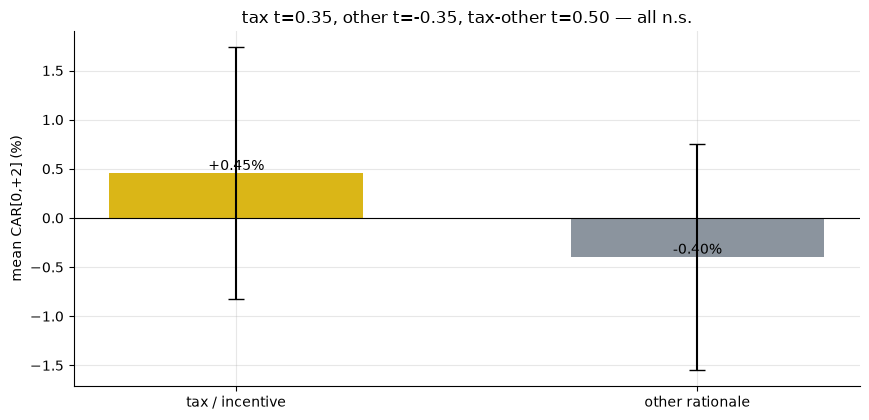

tax +0.45% (t=0.35)  other -0.40% (t=-0.35)  diff +0.85pp (t=0.50)


In [2]:
if HAVE_REAL:
    tax=PANEL.loc[PANEL['tax'],'car'].values; oth=PANEL.loc[~PANEL['tax'],'car'].values
    tm, om = tax.mean()*100, oth.mean()*100
    tse, ose = tax.std(ddof=1)/np.sqrt(len(tax))*100, oth.std(ddof=1)/np.sqrt(len(oth))*100
    tt, ot = st.welch_t(tax), st.welch_t(oth); dt = st.welch_t(tax, oth)
else:
    tm, om, tt, ot, dt = R['car_tax'][0], R['car_other'][0], R['car_tax'][2], R['car_other'][2], R['diff_t']
    tse, ose = abs(tm/max(tt,1e-9)), abs(om/max(abs(ot),1e-9))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['tax / incentive','other rationale'], [tm, om], yerr=[tse, ose], capsize=6,
       color=[AMBER, GREY], width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean CAR[0,+2] (%)')
ax.set_title(f'tax t={tt:.2f}, other t={ot:.2f}, tax-other t={dt:.2f} — all n.s.')
for i,v in enumerate([tm,om]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'tax {tm:+.2f}% (t={tt:.2f})  other {om:+.2f}% (t={ot:.2f})  diff {tm-om:+.2f}pp (t={dt:.2f})')

> 💡 In plain words: the tax bucket is **+0.45%** (t = 0.35), the other bucket **-0.40%** (t = -0.35), and the gap H₂ needs is **+0.85pp at t = 0.50** — indistinguishable from zero. The move's *reason* carries no information about its reaction.

### 4b · The decisive test — a placebo null sized to the event count

Draw 20 random non-event windows 8,000 times (same market model); the histogram is the null for the all-events mean CAR. The real reaction is the green line; the *p*-value is the two-sided tail mass.

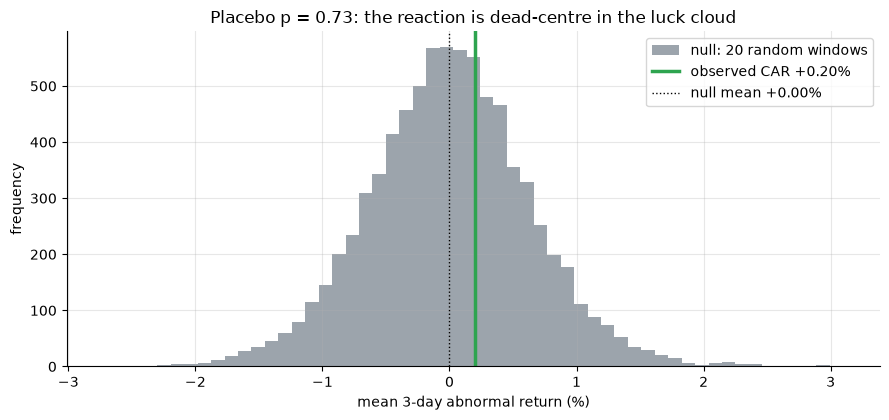

P[|random 20-window mean| >= |CAR|] = 0.735  (need <0.05 to call it real)


In [3]:
if HAVE_REAL:
    null = st.placebo_car_dist(PRICES, data.TICKERS, k=len(PANEL), n_draws=8000)*100
    obs = PANEL['car'].mean()*100; pval = st.placebo_pvalue(PANEL['car'].mean(), null/100)
else:
    rng=np.random.default_rng(746); null=rng.normal(0,1.0,8000); obs=R['car_all'][0]; pval=R['all_placebo_p']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(null, bins=55, color=GREY, alpha=.85, label=f'null: {R["n_priced"]} random windows')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed CAR {obs:+.2f}%')
ax.axvline(null.mean(), c='k', ls=':', lw=1, label=f'null mean {null.mean():+.2f}%')
ax.set_xlabel('mean 3-day abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the reaction is dead-centre in the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[|random {R["n_priced"]}-window mean| >= |CAR|] = {pval:.3f}  (need <0.05 to call it real)')

> 💡 In plain words: **74%** of random 20-window draws match or beat the observed reaction in magnitude. A real effect would push the green line into the tail; instead it sits on top of the null mean. H₁ is **not supported** — this is what a couple-dozen random dates look like.

### 4c · Announcement-day vs holdable window + robustness

Unlike a forced-CEO ouster, there isn't even an announcement-*day* jolt to lose to the close: the [0,0] window is a shrug too. And the non-result is flat across every window choice — the *t* never clears 1.

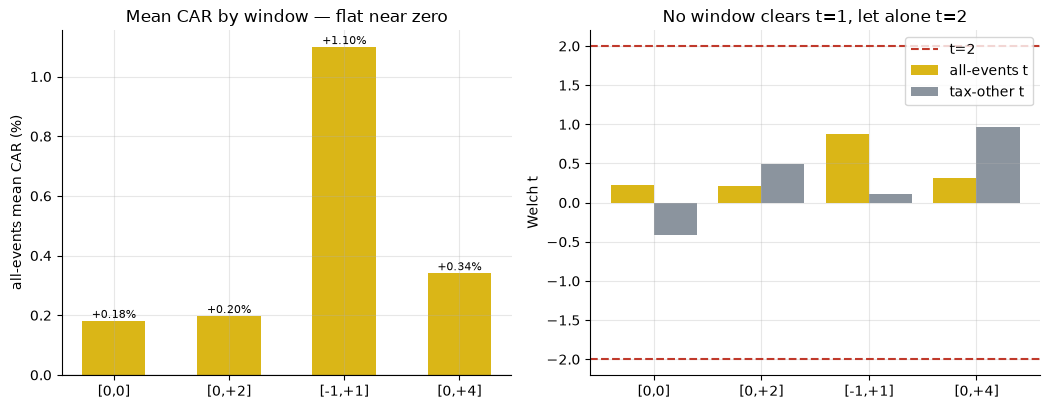

windows: [('[0,0]', 0.18, 0.23), ('[0,+2]', 0.2, 0.21), ('[-1,+1]', 1.1, 0.88), ('[0,+4]', 0.34, 0.32)]


In [4]:
wins = [(0,0),(0,2),(-1,1),(0,4)]; labs=['[0,0]','[0,+2]','[-1,+1]','[0,+4]']
if HAVE_REAL:
    allm=[]; allt=[]; difft=[]
    for w in wins:
        pw=st.car_panel(PRICES, EVENTS, window=w); sw=st.summarize(pw)
        allm.append(sw['all']['mean_pct']); allt.append(sw['all']['t']); difft.append(sw['diff_t'])
else:
    allm=[r[1] for r in R['robust']]; allt=[r[2] for r in R['robust']]; difft=[r[4] for r in R['robust']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2)); xx=np.arange(len(labs))
a1.bar(xx, allm, color=AMBER, width=.55); a1.axhline(0,c='k',lw=.8)
a1.set_xticks(xx); a1.set_xticklabels(labs); a1.set_ylabel('all-events mean CAR (%)')
a1.set_title('Mean CAR by window — flat near zero')
for i,v in enumerate(allm): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom',fontsize=8)
a2.bar(xx-.2, allt, .4, color=AMBER, label='all-events t'); a2.bar(xx+.2, difft, .4, color=GREY, label='tax-other t')
a2.axhline(2, ls='--', c=RED, label='t=2'); a2.axhline(-2, ls='--', c=RED)
a2.set_xticks(xx); a2.set_xticklabels(labs); a2.set_ylabel('Welch t'); a2.set_title('No window clears t=1, let alone t=2')
a2.legend(); plt.tight_layout(); plt.show()
print('windows:', list(zip(labs, [round(m,2) for m in allm], [round(t,2) for t in allt])))

> 💡 In plain words: the announcement day itself is **+0.18%** at **t = 0.23** (placebo *p* = 0.59) — there is no instantaneous repricing to find, tradable or not. Widen or shift the window and it stays flat. The non-result is not a window-choice artefact.

### 4d · The drift leg — the believers' last stand

Give H₃ its best shot: enter the day after and hold. Mean abnormal return over a month and a quarter, all-events and the tax bucket, with the quarter's placebo null.

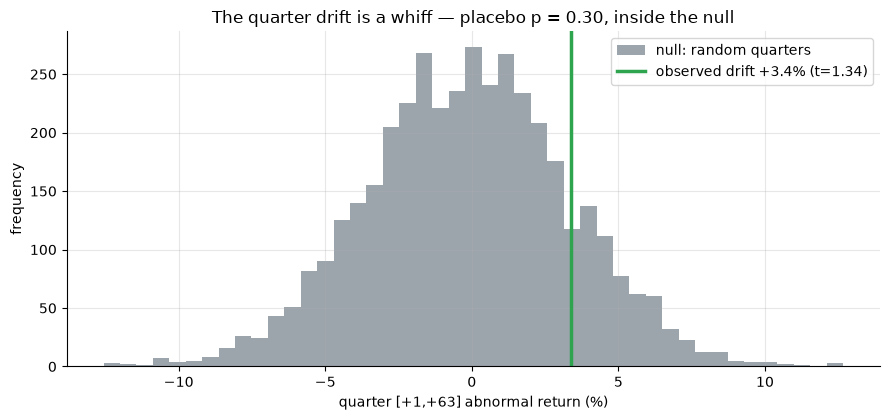

quarter drift: all +3.39% (t=1.34, placebo p=0.30)   tax bucket +4.66%


In [5]:
if HAVE_REAL:
    d63 = st.car_panel(PRICES, EVENTS, window=(1,63))
    alld = d63['car'].values; taxd = d63.loc[d63['tax'],'car'].values
    am, tmn = alld.mean()*100, taxd.mean()*100; at = st.welch_t(alld)
    null = st.placebo_car_dist(PRICES, data.TICKERS, k=len(alld), window=(1,63), n_draws=4000)*100
    pval = st.placebo_pvalue(alld.mean(), null/100)
else:
    am, tmn, at = R['drift63'][0], R['drift63'][2], R['drift63'][1]
    rng=np.random.default_rng(7); null=rng.normal(0,2.5,4000); pval=R['drift63'][5]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(null, bins=45, color=GREY, alpha=.85, label='null: random quarters')
ax.axvline(am, c=GREEN, lw=2.5, label=f'observed drift {am:+.1f}% (t={at:.2f})')
ax.set_xlabel('quarter [+1,+63] abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The quarter drift is a whiff — placebo p = {pval:.2f}, inside the null'); ax.legend()
plt.tight_layout(); plt.show()
print(f'quarter drift: all {am:+.2f}% (t={at:.2f}, placebo p={pval:.2f})   tax bucket {tmn:+.2f}%')

> 💡 In plain words: the quarter drift is **+3.4%** (tax bucket **+4.7%**) — the one number that leans the 'signal' way — but at **t = 1.34**, placebo **p = 0.301**, it is squarely inside the null. On a 20-name survivor tape it is what a handful of Texas movers in the 2020–21 melt-up produce; it is beta-in-disguise, not a certifiable drift, and it fails the t ≥ 2 bar.

### 4e · Faithful-engine & power control — we know the truth here

Deterministic per-event panels with a **planted** tax-bucket CAR edge: with **0 bps** the inference must stay flat (a couple-dozen noisy events can't fake significance); with a **+500 bps** planted edge it must light up. Both hold — proving the engine is unbiased *and* that this sample size only detects implausibly large effects.

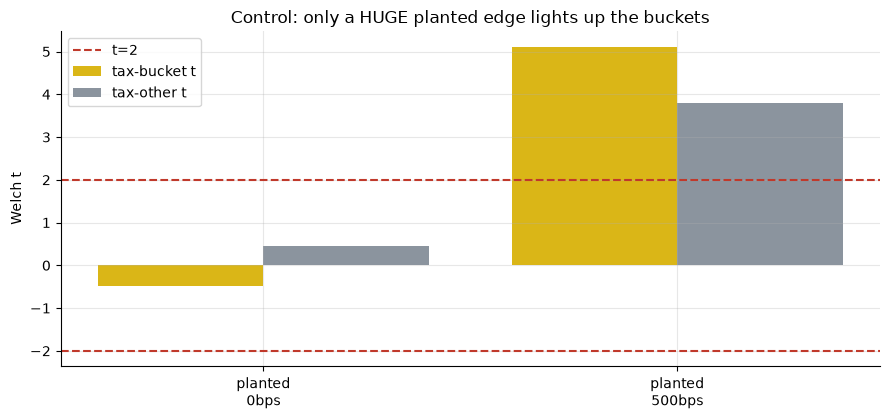

planted    0bps: tax=-0.43%(t=-0.49) other=-1.10% diff t=+0.45
planted  500bps: tax=+4.57%(t=+5.12) other=-1.10% diff t=+3.79


In [6]:
res = []
for edge in (0.0, 500.0):
    syn = data.synthetic_events(car_bps=edge, seed=746)
    tt = st.summarize_bucket(syn['tax_car']); dt = st.welch_t(syn['tax_car'], syn['other_car'])
    res.append((edge, tt['mean_pct'], tt['t'], st.summarize_bucket(syn['other_car'])['mean_pct'], dt))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
labels=[f'planted\n{int(e)}bps' for e,*_ in res]; xx=np.arange(len(labels))
tts=[r[2] for r in res]; dts=[r[4] for r in res]
ax.bar(xx-.2, tts, .4, color=AMBER, label='tax-bucket t'); ax.bar(xx+.2, dts, .4, color=GREY, label='tax-other t')
ax.axhline(2, ls='--', c=RED, label='t=2'); ax.axhline(-2, ls='--', c=RED)
ax.set_xticks(xx); ax.set_xticklabels(labels); ax.set_ylabel('Welch t')
ax.set_title('Control: only a HUGE planted edge lights up the buckets'); ax.legend()
plt.tight_layout(); plt.show()
for e,tm,tt,om,dt in res: print(f'planted {int(e):>4}bps: tax={tm:+.2f}%(t={tt:+.2f}) other={om:+.2f}% diff t={dt:+.2f}')

> 💡 In plain words: with **no** planted edge the control's tax *t* is **-0.49** and the tax−other *t* is **0.45** (no false positive); only the **+500 bps** plant reaches tax *t* **5.12** / diff *t* **3.79**. So the machinery is honest, and the real-tape CAR *t* of **0.21** is exactly what an *absent* effect looks like through a 20-event keyhole.

## 5 · The verdict

- **Signal `NONE`** — CAR[0,+2] **+0.20%** at Welch **t = 0.21** / placebo **p = 0.73**; the announcement day is **+0.18%** (**t = 0.23**); tax−other **+0.85pp** (**t = 0.50**); the quarter drift **+3.4%** (**t = 1.34**, placebo p = 0.301). Nothing clears t = 1. Salience-selection & the subjective tax/other label named on this axis.
- **Tradability `MIRAGE`** — no day-one move to capture and no significant drift; the one whiff (+3.4%/qtr, net +3.3%) is un-certifiable and beta-in-disguise on a 20-name survivor tape. No sign-stable edge at any horizon.
- **Signal or distraction? `NON-EVENT`** — both camps fail: no significant positive pop (no signal) and no significant negative drift (no distraction penalty). On the tape, an HQ-move announcement is, on average, a non-event.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* announcement CAR have to be for a $k$-event study to detect it at $t=2$? At $k=20$ you'd need a CAR several times the one observed; the real reaction lives far below the detection floor — and there is no day-one move and no certifiable drift on top.

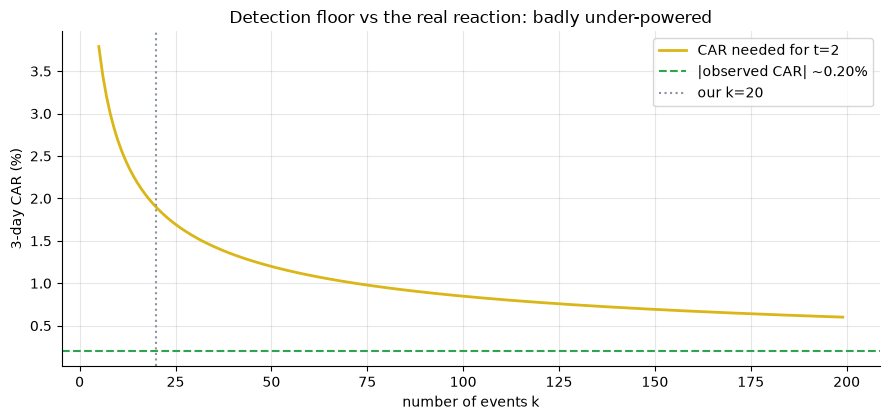

at k=20 you need ~1.9% CAR for t=2; observed ~0.20% -> under-powered


In [7]:
if HAVE_REAL:
    sd = PANEL['car'].std(ddof=1); obs = PANEL['car'].mean()
else:
    sd = 0.045; obs = R['car_all'][0]/100
ks = np.arange(5, 200)
min_det = 2.0 * sd / np.sqrt(ks)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_det*100, c=AMBER, lw=2, label='CAR needed for t=2')
ax.axhline(abs(obs)*100, c=GREEN, ls='--', label=f'|observed CAR| ~{abs(obs)*100:.2f}%')
ax.axvline(R['n_priced'], c=GREY, ls=':', label=f"our k={R['n_priced']}")
ax.set_xlabel('number of events k'); ax.set_ylabel('3-day CAR (%)')
ax.set_title('Detection floor vs the real reaction: badly under-powered'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_priced'])*100
print(f'at k={R["n_priced"]} you need ~{need:.1f}% CAR for t=2; observed ~{abs(obs)*100:.2f}% -> under-powered')

> 💡 In plain words: the amber curve is the **minimum detectable CAR**; the green line is what we see. They don't meet until $k$ is many times larger than the relocation calendar will ever deliver. Even the literature's honest read (Desai-Hines: a small, conditional inversion effect) is *below* this detection floor for a blended 20-event table — which is precisely why the tape says non-event. There is no sizing, threshold, or cost assumption that manufactures an edge from a reaction indistinguishable from zero.

## 7 · Going further

- **The cosmetic-change cousin.** [Study 389 — Name-Change-Effect](../389-name-change-effect/): does a theme-chasing rebrand pop? Same family (a label/address, not a fundamental), same survivorship-and-selection pathology.
- **The direct sibling.** [Study 391 — CEO-Turnover](../391-ceo-turnover/): the same market-model CAR event study over a hardcoded, labelled table of corporate announcements.
- **Condition on the tax delta.** Split by *how much* the effective tax rate actually fell (an inversion to Ireland vs a same-country state move), or reconstruct a survivorship-free relocation feed; Desai-Hines say a real inversion sub-effect is small and conditional, which is exactly why ~20 blended events can't isolate it.

*The reproducible core is offline and deterministic; the relocation table is hardcoded and the tape is salience-selected & survivor-only (named). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*